<a href="https://colab.research.google.com/github/baro4ka/SF/blob/main/Eco_monitor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1.Монтируем каталог данных
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 2. Задаем пути, делаем импорты и настраиваем окна

# === Пути ===
import os
BASE_DIR      = "/content/drive/MyDrive"          # Корень проекта на Google Drive (куда монтируется MyDrive)
DATASET_DIR   = os.path.join(BASE_DIR, "birds_saved_full")       # Папка со слепком датасета birdsounds
ARTIFACTS_DIR = os.path.join(BASE_DIR, "bird_monitor_artifacts") # Папка с дообученной моделью и label encoder

clf_path = os.path.join(ARTIFACTS_DIR, "clf_yamnet_birds.keras") # Файл Keras‑модели‑классификатора птиц
le_path  = os.path.join(ARTIFACTS_DIR, "label_encoder.pkl")      # Файл LabelEncoder с маппингом id → вид

print("DATASET_DIR:", DATASET_DIR)
print("clf_path   :", clf_path)
print("le_path    :", le_path)

# === Импорты ===
import io
import numpy as np
import soundfile as sf   # Чтение аудио из байтов/файлов (OGG/WAV)
import tensorflow as tf
import tensorflow_hub as hub
from datasets import load_from_disk, Audio   # Работа со слепком датасета
from collections import Counter              # Подсчет детекций видов
import matplotlib.pyplot as plt              # Построение гистограммы активности видов
import joblib                               # Загрузка сохраненного LabelEncoder
from tensorflow.keras.models import load_model  # Загрузка Keras‑модели классификатора

# === Параметры окон ===
SR          = 16000   # Целевая частота дискретизации аудио (Гц)
WIN_SEC     = 5.0     # Длительность одного окна анализа (секунды)
HOP_SEC     = 2.5     # Шаг смещения окна (секунды) — задает перекрытие
WIN_SAMPLES = int(SR * WIN_SEC)  # Размер окна в сэмплах
HOP_SAMPLES = int(SR * HOP_SEC)  # Шаг окна в сэмплах

def split_into_windows(y, win_samples=WIN_SAMPLES, hop_samples=HOP_SAMPLES):
    """
    Разбивает сигнал на перекрывающиеся окна фиксированной длины.
    Последнее окно при необходимости дополняется нулями (паддинг), чтобы
    все окна были одинаковой длины win_samples.

    Параметры:
      y           — одномерный аудиосигнал (numpy-массив)
      win_samples — длина окна в сэмплах
      hop_samples — шаг сдвига окна в сэмплах

    Возвращает:
      массив формы (num_windows, win_samples), где каждая строка — одно окно.
    """
    y = np.asarray(y, dtype=np.float32)
    if len(y) == 0:
        return np.zeros((1, win_samples), dtype=np.float32)

    windows = []
    for start in range(0, max(len(y) - win_samples + 1, 1), hop_samples):
        end = start + win_samples
        if end > len(y):
            pad = end - len(y)
            y_pad = np.pad(y[start:], (0, pad))   # Дополняем нулями до нужной длины
        else:
            y_pad = y[start:end]
        windows.append(y_pad.astype(np.float32))

    return np.stack(windows)

DATASET_DIR: /content/drive/MyDrive/birds_saved_full
clf_path   : /content/drive/MyDrive/bird_monitor_artifacts/clf_yamnet_birds.keras
le_path    : /content/drive/MyDrive/bird_monitor_artifacts/label_encoder.pkl


In [3]:
# 3. Загружаем и настраиваем предобученную модель YAMNet

# URL предобученной модели YAMNet на TensorFlow Hub.
# Модель обучена на датасете Birdsounds и умеет извлекать признаки звуков окружающей среды.
YAMNET_HANDLE = "https://tfhub.dev/google/yamnet/1"

# Загружаем модель из TF Hub в оперативную память (как SavedModel).
yamnet = hub.load(YAMNET_HANDLE)

def yamnet_embed(waveform_1d):
    """
    Получает эмбеддинг и усредненные оценки классов YAMNet для одного аудиосигнала.

    Параметры:
      waveform_1d — одномерный numpy-массив аудио (моно) с частотой 16 кГц.

    Возвращает:
      emb_mean    — усредненный по времени вектор эмбеддинга (признаки для классификатора птиц);
      scores_mean — усредненное по времени распределение вероятностей классов YAMNet.
    """
    # Преобразуем сигнал в тензор float32 для подачи в модель YAMNet.
    wf = tf.convert_to_tensor(waveform_1d, dtype=tf.float32)

    # Модель YAMNet возвращает:
    # scores      — построговые вероятности классов Birdsounds для каждого фрейма,
    # embeddings  — вектора признаков для каждого фрейма,
    # spectrogram — внутреннее представление спектрограммы.
    scores, embeddings, spectrogram = yamnet(wf)

    # Усредняем эмбеддинги и оценки по временной оси,
    # чтобы получить один вектор признаков и одно распределение классов на всё окно.
    return embeddings.numpy().mean(axis=0), scores.numpy().mean(axis=0)

In [4]:
# 4. Создаем классификатор

# Модель‑классификатор и label encoder
print("\nЗагрузка модели и энкодера")

# Загружаем дообученную Keras‑модель, которая по эмбеддингу YAMNet
# предсказывает вероятность принадлежности к одному из видов птиц.
clf = load_model(clf_path)

# Загружаем сохранённый LabelEncoder.
# Он содержит соответствие: числовой индекс класса ↔ строковое название вида.
le  = joblib.load(le_path)

print("Модель и encoder загружены, классов:", len(le.classes_))

# KEY_SPECIES — список "ключевых" видов (первые 5 классов из encoder).
# По ним можно строить более строгие правила аномалий (например, отсутствие части ключевых видов считать подозрительным сигналом).
KEY_SPECIES = le.classes_[:5]


Загрузка модели и энкодера
Модель и encoder загружены, классов: 17


In [5]:
# 5. Загружаем датасет (без декодирования, bytes + path)

print("\nЗагрузка датасета с диска")

# Загружаем слепок датасета из локальной папки DATASET_DIR.
# Это сохранённая копия датасета Saads/birdsounds (аудио + метки видов).
raw_ds = load_from_disk(DATASET_DIR)

# Общее число сэмплов и список столбцов (ожидаются 'audio' и 'label').
print("Сэмплов в raw_ds:", len(raw_ds))
print("Колонки:", raw_ds.column_names)

# Берём схему признаков (features) исходного датасета.
features = raw_ds.features

# Переопределяем тип столбца 'audio' так, чтобы:
#  - данные НЕ декодировались автоматически в массивы (decode=False),
#  - внутри 'audio' хранились только bytes и относительный путь (path).
# Это позволяет обойти требования к установке torch/torchcodec.
features["audio"] = Audio(decode=False)

# Приводим колонку 'audio' к новому типу.
ds = raw_ds.cast_column("audio", features["audio"])

print("Пример audio[0]:")
# Проверяем структуру первого элемента аудио:
# ожидаем dict вида {'bytes': ..., 'path': 'XC123456.ogg'}.
print(ds[0]["audio"].keys())  # bytes, path


Загрузка датасета с диска
Сэмплов в raw_ds: 16941
Колонки: ['audio', 'label']
Пример audio[0]:
dict_keys(['bytes', 'path'])


In [6]:
# 6. Задаем вспомогательные функции

def decode_audio_from_bytes(audio_bytes, target_sr=SR):
    """
    Декодирует «сырые» аудиобайты (OGG/WAV) в numpy‑массив и приводит сигнал
    к целевой частоте дискретизации.

    Параметры:
      audio_bytes — байтовое содержимое аудиофайла (поле 'bytes' из датасета);
      target_sr   — целевая частота дискретизации (по умолчанию SR = 16000 Гц).

    Возвращает:
      y  — одномерный numpy‑массив аудиосигнала (моно, float32);
      sr — фактическая частота дискретизации после преобразований.
    """
    # Читаем звук напрямую из байтового буфера через soundfile.
    with io.BytesIO(audio_bytes) as f:
        y, sr = sf.read(f, dtype="float32")

    # Если звук многоканальный (стерео и т.п.) — усредняем каналы до моно.
    if y.ndim > 1:
        y = np.mean(y, axis=1)

    # При необходимости приводим частоту дискретизации к target_sr.
    if sr != target_sr:
        import librosa
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
        sr = target_sr

    return y, sr


def analyze_soundscape_indices(indices):
    """
    Анализирует набор записей по индексам датасета и возвращает сводную
    статистику по видам и окнам.

    Параметры:
      indices — список индексов примеров в датасете ds, которые нужно проанализировать.

    Возвращает словарь:
      {
        "counts": Counter по видам (вид -> количество детекций),
        "active_species": число видов с хотя бы одной детекцией,
        "total_windows": общее количество проанализированных окон,
        "anomaly": флаг аномалии (True/False)
      }
    """
    species_counter = Counter()  # сюда накапливаются детекции по видам
    total_windows = 0            # общее количество окон, обработанных моделью

    for idx in indices:
        audio_obj = ds[idx]["audio"]      # {'bytes': ..., 'path': ...}
        audio_bytes = audio_obj["bytes"]  # берём сырые байты аудио

        # Декодируем байты в сигнал y с частотой SR.
        y, sr = decode_audio_from_bytes(audio_bytes, target_sr=SR)

        # Нормализация по амплитуде (чтобы избежать влияния громкости).
        m = np.max(np.abs(y)) if len(y) > 0 else 0.0
        if m > 0:
            y = y / m

        # Разбиваем сигнал на перекрывающиеся окна фиксированной длины.
        windows = split_into_windows(y, win_samples=WIN_SAMPLES, hop_samples=HOP_SAMPLES)

        # Для каждого окна считаем эмбеддинг и предсказываем вид.
        for w in windows:
            emb, _ = yamnet_embed(w)                          # эмбеддинг YAMNet
            probs = clf.predict(emb[None, :], verbose=0)[0]   # предсказание классификатора
            pred_id = np.argmax(probs)                        # индекс наиболее вероятного вида
            species = le.inverse_transform([pred_id])[0]      # строковое имя вида
            species_counter[species] += 1
            total_windows += 1

    # Число активных видов — сколько видов встретилось хотя бы один раз.
    active_species = sum(1 for c in species_counter.values() if c > 0)

    # Простое правило аномалии: если видов меньше половины ключевых (KEY_SPECIES), считаем аномалией.
    anomaly = active_species < max(1, len(KEY_SPECIES) // 2)

    return {
        "counts": species_counter,
        "active_species": active_species,
        "total_windows": total_windows,
        "anomaly": anomaly,
    }


def plot_top_species(stats, top_k=10):
    """
    Строит гистограмму самых часто встречающихся видов.

    Параметры:
      stats — словарь, возвращаемый analyze_soundscape_indices;
      top_k — сколько видов показывать на графике (по убыванию активности).
    """
    counts = stats["counts"]
    most_common = counts.most_common(top_k)
    if not most_common:
        print("Нет данных для визуализации")
        return

    labels = [x[0] for x in most_common]  # названия видов
    values = [x[1] for x in most_common]  # количество детекций

    plt.figure(figsize=(10, 4))
    plt.bar(labels, values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Количество детекций")
    plt.title("Топ видов по активности")
    plt.tight_layout()
    plt.show()


=== Запуск анализа ===
Активных видов: 10
Всего окон: 217
Аномалия: False


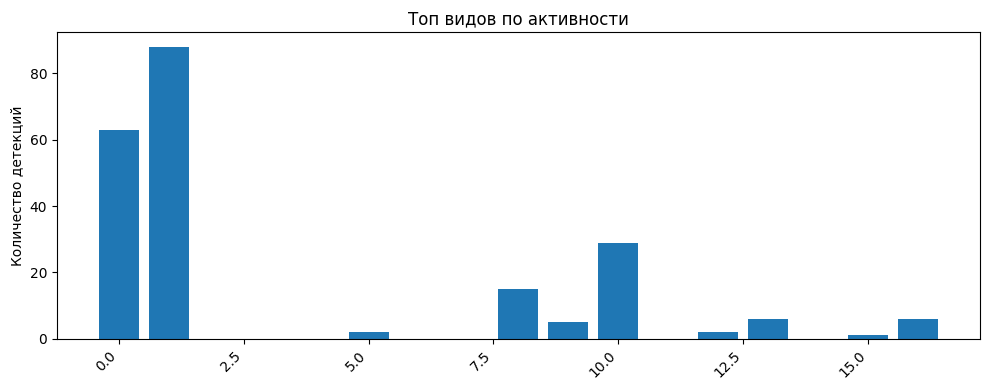

In [ ]:
# 7. Запускаем анализ

print("\nЗапуск анализа")

# Список индексов записей, которые будем анализировать.
# Здесь берём первые 20 сэмплов датасета — это можно менять в зависимости от задачи.
test_indices = list(range(20))

# Запускаем основной анализ звуковой среды по выбранным индексам.
stats = analyze_soundscape_indices(test_indices)

# Выводим числовые показатели:
print("Активных видов:", stats["active_species"])   # сколько разных видов зафиксировано
print("Всего окон:", stats["total_windows"])        # сколько временных окон проанализировано
print("Аномалия:", stats["anomaly"])               # флаг: обнаружена ли аномалия (True/False)

# Строим гистограмму активности видов по результатам анализа.
plot_top_species(stats)

---
# Расчет точности модели

In [7]:
from datasets import load_from_disk, Audio

raw_ds = load_from_disk(DATASET_DIR)
features = raw_ds.features
features["audio"] = Audio(decode=False)
raw_ds = raw_ds.cast_column("audio", features["audio"])

In [8]:
# Подготовим легковесный список для оценки: (audio_bytes, true_id)
eval_data = []

n_all = len(raw_ds)
n = min(2000, n_all)  # можно ограничить, чтобы не тащить весь датасет
print(f"Готовим eval_data из {n} записей")

for idx in range(n):
    row = raw_ds[idx]              # здесь ещё может дернуться decode, поэтому делаем один раз
    audio_bytes = row["audio"]["bytes"]
    true_id = row["label"]
    eval_data.append((audio_bytes, true_id))

print("Размер eval_data:", len(eval_data))

Готовим eval_data из 2000 записей
Размер eval_data: 2000


In [9]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

def evaluate_classifier_from_eval_data(max_samples=1000):
    """
    Оценивает точность классификатора, используя заранее подготовленный список eval_data.
    eval_data: список (audio_bytes, true_id).
    Примеры с метками, отсутствующими в encoder, пропускаются.
    """
    y_true = []
    y_pred = []

    n = min(max_samples, len(eval_data))
    print(f"Оцениваем на {n} записях (из eval_data)")

    known_ids = set(range(len(le.classes_)))  # допустимые индексы классов, например 0..16

    skipped = 0
    for i in range(n):
        audio_bytes, true_id = eval_data[i]

        # Пропускаем метки, которых нет в encoder (например, класс 17)
        if true_id not in known_ids:
            skipped += 1
            continue

        true_species = le.inverse_transform([true_id])[0]

        # декодирование из bytes -> сигнал
        y, sr = decode_audio_from_bytes(audio_bytes, target_sr=SR)

        # нормализация
        m = np.max(np.abs(y)) if len(y) > 0 else 0.0
        if m > 0:
            y = y / m

        # один эмбеддинг на всю запись
        emb, _ = yamnet_embed(y)
        probs = clf.predict(emb[None, :], verbose=0)[0]
        pred_id = np.argmax(probs)
        pred_species = le.inverse_transform([pred_id])[0]

        y_true.append(true_species)
        y_pred.append(pred_species)

    print(f"Пропущено примеров с неизвестными метками: {skipped}")

    if not y_true:
        print("Нет валидных примеров для оценки.")
        return None, [], []

    acc = accuracy_score(y_true, y_pred)
    print(f"\nAccuracy на {len(y_true)} валидных записях: {acc:.3f}\n")
    print("Отчёт по классам:")
    print(classification_report(y_true, y_pred, zero_division=0))
    return acc, y_true, y_pred

In [10]:
# Запускать после определения вспомогательных функций
acc, y_true, y_pred = evaluate_classifier_from_eval_data(max_samples=1000)
print("Сохранённая accuracy:", acc)

Оцениваем на 1000 записях (из eval_data)
Пропущено примеров с неизвестными метками: 184

Accuracy на 816 валидных записях: 0.799

Отчёт по классам:
              precision    recall  f1-score   support

           0       0.88      0.47      0.61        15
           1       0.78      0.92      0.85       126
           2       0.73      0.68      0.70        28
           3       0.69      0.50      0.58        18
           4       0.91      0.68      0.78        31
           5       0.84      0.87      0.85        90
           6       1.00      0.71      0.83        48
           7       1.00      0.25      0.40         8
           8       0.85      0.93      0.89        72
           9       0.86      0.84      0.85        37
          10       0.61      0.86      0.71       104
          11       1.00      1.00      1.00         1
          12       0.90      0.78      0.83        81
          13       0.86      0.88      0.87        57
          14       0.69      0.80      0.